### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [73]:
import pandas as pd
df = pd.read_csv("D:/carrie works/SFU_Prepare/882/lab02-EDA/grades_crpt.csv")

### Explore Data

In [74]:
df.head(5)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [75]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


In [76]:
df['user_id'].nunique() #check for duplication

86

In [77]:
df.shape

(86, 9)

In [78]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


In [79]:
import matplotlib.pyplot as plt
# this plotting function I use it to visualize data and use it to make sure 
# that the conclusions I made from the describtive summary are correct  
def hist_plot (data, title):
    # Plotting a basic histogram
    plt.hist(data, bins=30, color='skyblue', edgecolor='black')
    
    # Adding labels and title
    plt.xlabel('Grades')
    plt.ylabel('Frequency')
    plt.title(title)
    
    # Display the plot
    plt.show()

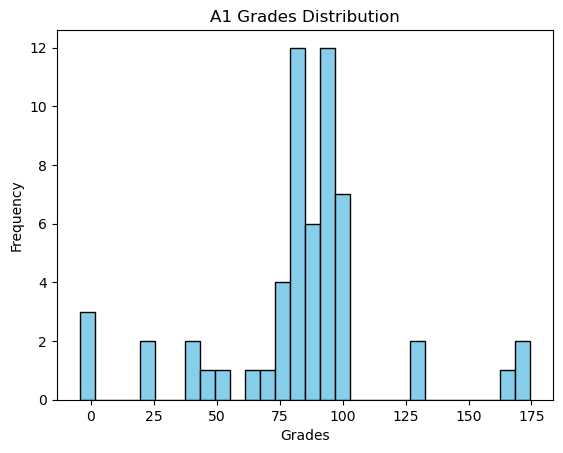

In [80]:
hist_plot(df["A1"], 'A1 Grades Distribution')

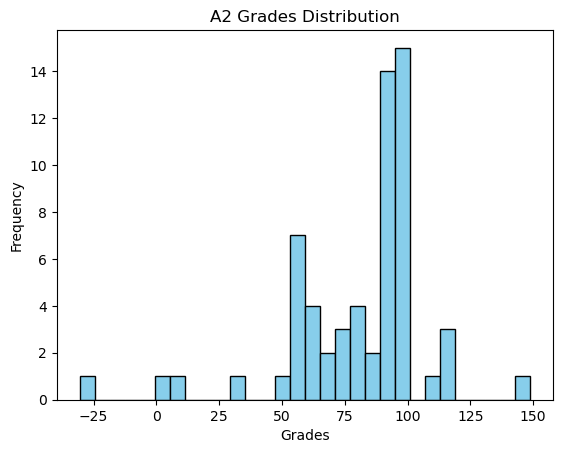

In [81]:
hist_plot(df["A2"], 'A2 Grades Distribution')

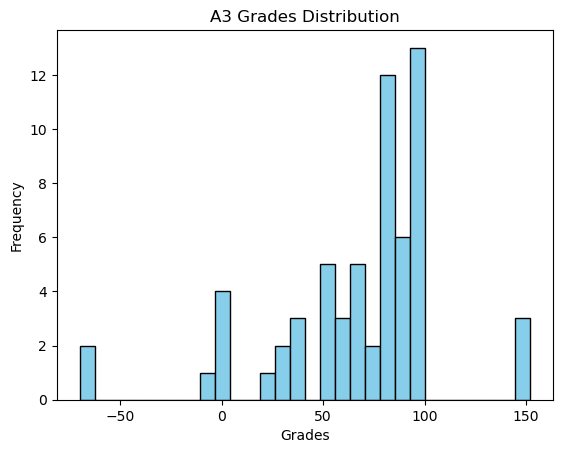

In [82]:
hist_plot(df["A3"], 'A3 Grades Distribution')

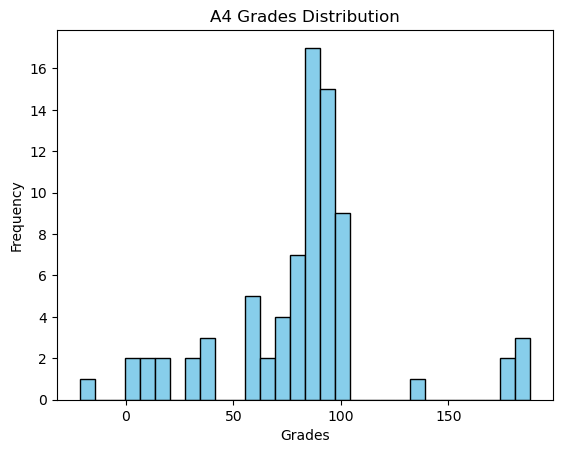

In [83]:
hist_plot(df["A4"], 'A4 Grades Distribution')

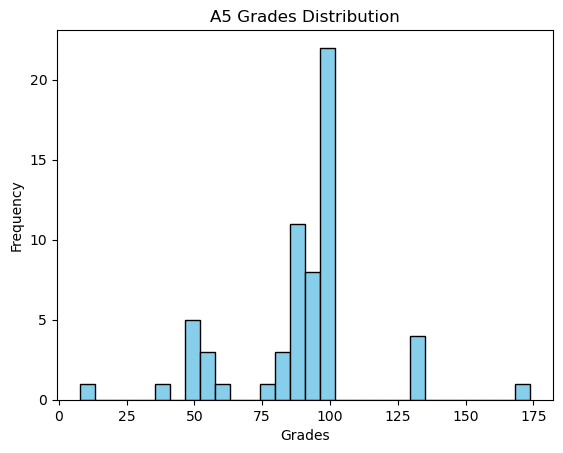

In [84]:
hist_plot(df["A5"], 'A5 Grades Distribution')

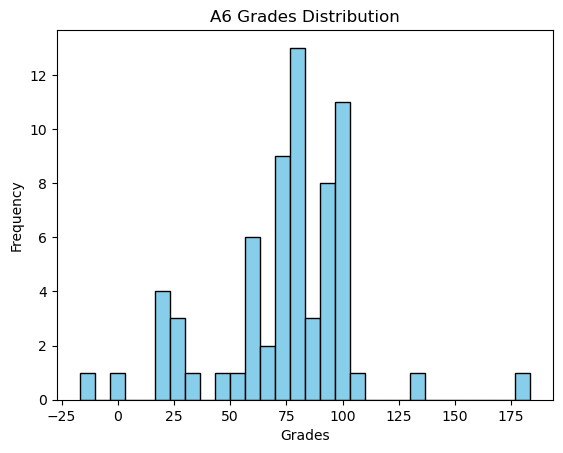

In [85]:
hist_plot(df["A6"], 'A6 Grades Distribution')

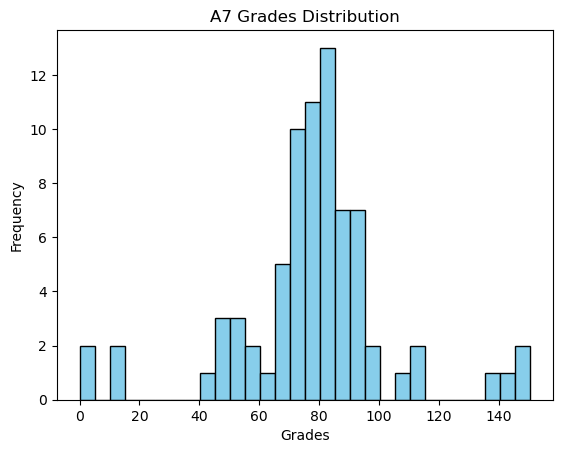

In [86]:
hist_plot(df["A7"], 'A7 Grades Distribution')

## Notes on Data

I am assuming that the full mark is 100 

I assume that grades in negative is not possible as well (done an engineering class where it was lol)

the data have 86 records

**A1**

min value is negative that is an error

max value exceeds 100 + this assignment does not have any bonus points

29 missing values

**A2**

min value is negative that is an error

max value exceeds 100 + this assignment has up to 15 bonus points which still the max value exceeds

25 missing values


**A3**

min value is negative that is an error

max value exceeds 100 + this assignment does not have any bonus points

24 missing values

**A4**

min value is negative that is an error

max value exceeds 100 + this assignment has up to 5 bonus points which still the max value exceeds

9 missing values

**A5**

max value exceeds 100 + this assignment does not have any bonus points

25 missing values

**A6**

min value is negative that is an error

max value exceeds 100 + this assignment has up to 10 bonus points which still the max value exceeds

19 missing values

**A7**

max value exceeds 100 + this assignment does not have any bonus points

10 missing values

### Check Correlations

In [87]:
import seaborn as sns

# as I will be checking correlation multiple times I made two functions to calculate and visualize correlation matrix

def correlation_check(df1):
    assignment_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam'] # columns list
    corr_matrix = df1[assignment_cols].corr() # calculate correlation matrix
    print(corr_matrix.round(2)) 
    return corr_matrix

def plot_heatmatrix (corr_matrix): #plot correlation matrix as a heat map
    plt.figure(figsize=(8,6 ))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.tight_layout()
    plt.show()


In [88]:
corr_matrix = correlation_check(df)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


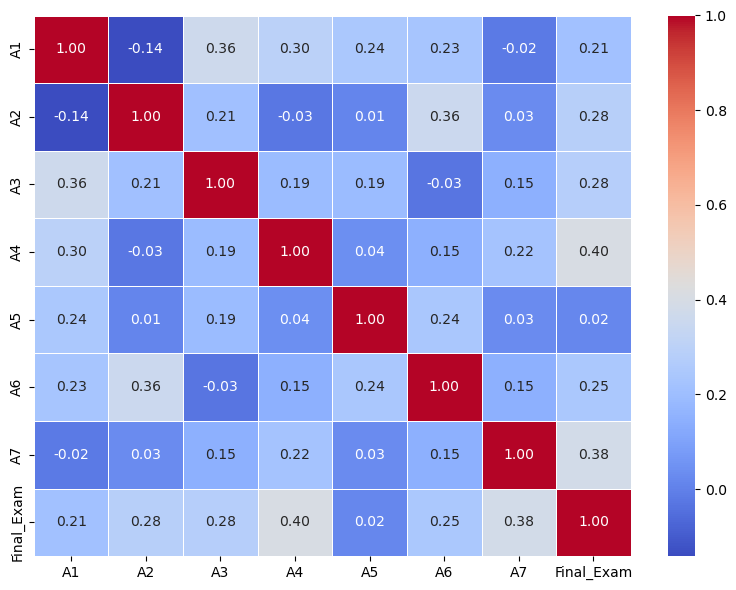

In [89]:
plot_heatmatrix (corr_matrix)

## Correlation 
I consider *r < 0.25 is no correlation*, *r > 0.25 and < 0.50 to be a weak correlation*,

*r > 0.50 and < 0.75 to be a moderate correlation* and *r < 0.75 to be a strong correlation*

Currently as data is **not clean** there is no strong correlation however we can see that A4 (r=0.40) and A7 (r=0.38) show a weak correlation with final exam result. Also worth noticing is that A5 (r = 0.02) and A1 (r= 0.21) has no correlation with final exam results. While A2 (r= 0.28), A3 (r= 0.28), and A6 (r= 0.25) should be considered weak correlations according to the critiria I used their r values is way less than r values of A4 and A7.


**If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

 I think that A4 and A7 are the two assignments that have a correlation with final exam results that can be used to predict final results as the Pearson correlation coefficients between A4 and final results (r= 0.40) and A7 and final results (r=0.38) are the further away from zero which means they are the strongest relations among all assignments.

 missing values are the lowest in both columns as well

 and the distribution of grades is the colsest to normal in my opinion


## Handle the missing values and outliers

All columns have missing values we know that from data info reults and describtive summary

the data have 86 records

*A1
    29 missing values

*A2
    25 missing values

*A3
    24 missing values

*A4
    9 missing values

*A5
    25 missing values

*A6
    19 missing values

*A7
    10 missing values


## Remove missing data and outliers

In [207]:
clean_remove_df = df.copy() 

In [208]:
clean_remove_df.loc[clean_remove_df.isnull().any(axis=1)]

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
5,100.0,92.9,100.0,96.2,NaN,80.0,110.5,97.5,U006
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


In [92]:
clean_remove_df = clean_remove_df.dropna() #delet nan values

In [93]:
clean_remove_df

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3,U010
11,79.2,57.1,64.0,68.8,90.0,72.0,68.8,28.4,U012
30,83.3,100.0,60.0,183.1,90.0,70.0,78.8,49.1,U031
34,81.7,92.9,82.0,95.7,95.0,82.0,70.6,54.4,U035
52,41.7,58.9,-70.1,88.8,80.0,70.0,71.9,31.9,U053
53,66.7,57.1,30.0,37.5,90.0,60.0,77.5,49.4,U054
54,95.8,100.0,152.2,95.0,100.0,100.0,12.3,78.4,U055
59,91.7,92.9,98.0,98.2,7.7,88.0,81.2,81.2,U060


## Detecting outliers in each assignment

In [90]:
def detect_outliers(df, column, extra_p = 0):
    lower_bound = 0 # as I assume no grade should be less than zero
    higher_bound = 100 + extra_p # as I assume grades dont't exceed 100 + bonus if applicable
    return df[(df[column] < lower_bound) | (df[column] > higher_bound)] #return outliers in the dataset

def remove_outliers(df,column, extra_p = 0):
    outlier = detect_outliers(df,column, extra_p) #first I detect outliers
    userlist = outlier['user_id'].tolist() #I get user ids of outliers and convert it to list
    df = df[~df['user_id'].isin(userlist)].copy() #remove rows with outliers user ids
    return df #return dataset after outliers are removed

In [171]:
A1_outliers = detect_outliers(df,'A1')
A1_outliers['A1']

7     168.9
9     129.9
15    168.1
16    174.6
24    130.7
44     -4.5
Name: A1, dtype: float64

In [172]:
A2_outliers = detect_outliers(df,'A2', 15)
A2_outliers['A2']

44    148.9
82    -30.6
Name: A2, dtype: float64

In [173]:
A3_outliers = detect_outliers(df,'A3')
A3_outliers['A3']

9      -5.3
12    -69.3
16    149.2
26     -1.7
52    -70.1
54    152.2
66    150.8
Name: A3, dtype: float64

In [174]:
A4_outliers = detect_outliers(df,'A4', 5)
A4_outliers['A4']

6     175.8
24    188.2
28    133.8
30    183.1
36    187.1
67    -21.6
82    174.8
Name: A4, dtype: float64

In [175]:
A5_outliers = detect_outliers(df,'A5')
A5_outliers['A5']

56    132.0
60    131.8
61    173.9
62    131.4
73    133.4
Name: A5, dtype: float64

In [176]:
A6_outliers = detect_outliers(df,'A6', 10)
A6_outliers['A6']

12    183.6
45    136.4
76    -17.0
Name: A6, dtype: float64

In [177]:
A7_outliers = detect_outliers(df,'A7')
A7_outliers['A7']

5     110.5
14    142.1
50    136.9
58    110.3
68    150.6
72    112.3
82    146.4
Name: A7, dtype: float64

## Remove outliers

In [179]:
# remove outliers after nan was removed
def remove_from_col(clean_remove_df):
    assignment_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7'] #list of columns to loop through
    for assignment in assignment_cols: #for each column check if extra points is applicable then remove outliers
        extra_points= 0
        if assignment == 'A2':
            extra_points=15
        elif assignment == 'A4':
            extra_points= 5
        elif assignment == 'A6':
            extra_points= 10
        clean_remove_df = remove_outliers(clean_remove_df,assignment, extra_points) #call remove function after checking if bonus was applicable
    return clean_remove_df #return data after removing outliers

clean_remove_df= remove_from_col(clean_remove_df)
clean_remove_df

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
11,79.2,57.1,64.0,68.8,90.0,72.0,68.8,28.4,U012
34,81.7,92.9,82.0,95.7,95.0,82.0,70.6,54.4,U035
53,66.7,57.1,30.0,37.5,90.0,60.0,77.5,49.4,U054
59,91.7,92.9,98.0,98.2,7.7,88.0,81.2,81.2,U060


In [180]:
corr_matrix= correlation_check(clean_remove_df)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.18  0.72  0.95 -0.02  0.99  0.94        0.86
A2          0.18  1.00  0.72  0.45 -0.53  0.34 -0.05        0.40
A3          0.72  0.72  1.00  0.88 -0.44  0.81  0.46        0.67
A4          0.95  0.45  0.88  1.00 -0.09  0.99  0.80        0.83
A5         -0.02 -0.53 -0.44 -0.09  1.00 -0.07  0.13       -0.31
A6          0.99  0.34  0.81  0.99 -0.07  1.00  0.88        0.88
A7          0.94 -0.05  0.46  0.80  0.13  0.88  1.00        0.85
Final_Exam  0.86  0.40  0.67  0.83 -0.31  0.88  0.85        1.00


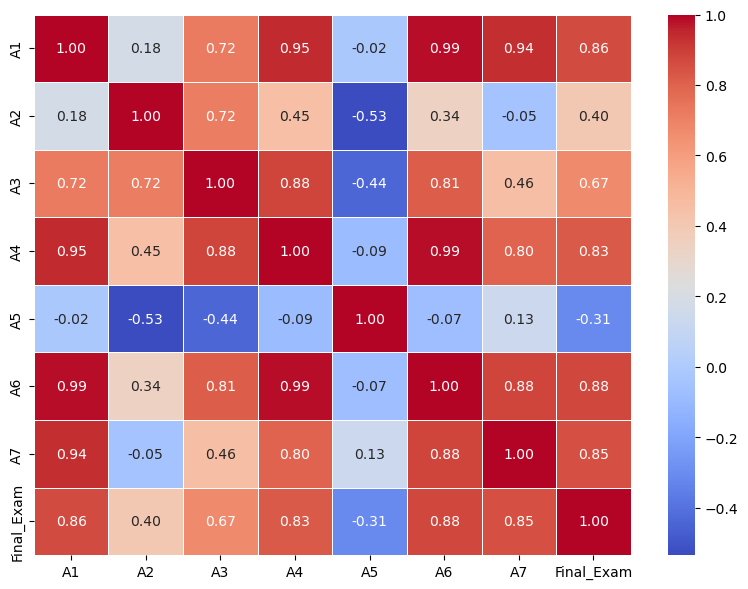

In [181]:
plot_heatmatrix (corr_matrix)

**After simply removing missing values and outliers the remaining data is 5 records this is a very small sample I can not trust the outcome so I don't think this method can be used with this data set** 

## Fill with mean

In [182]:
def fill_mean(df, column):
    df[column] = df[column].fillna(df[column].mean())
    return df

df_fill_avg = df.copy()
# df_fill_avg = df_fill_avg.drop(columns=['A1', 'A2', 'A3','A5','A6'])
for assignment in assignment_cols:
    df_fill_avg = fill_mean(df_fill_avg, assignment)
    

# df_fill_avg = fill_mean(df_fill_avg, 'A4')
# df_fill_avg = fill_mean(df_fill_avg, 'A7')

In [183]:
df_fill_avg

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,83.67193,81.096721,30.000000,75.0,90.000000,65.000000,50.600000,68.8,U001
1,100.00000,81.096721,68.174194,92.5,100.000000,100.000000,84.400000,50.3,U002
2,75.00000,69.600000,68.174194,86.2,100.000000,74.437313,78.130263,67.8,U003
3,25.00000,78.600000,40.000000,0.0,50.000000,30.700000,0.000000,0.0,U004
4,0.00000,81.096721,0.000000,0.0,89.645902,74.437313,78.130263,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,83.67193,81.096721,68.174194,56.2,89.645902,29.200000,60.000000,57.5,U082
82,87.50000,-30.600000,70.000000,174.8,91.000000,74.437313,146.400000,64.1,U083
83,79.20000,81.096721,60.000000,27.5,50.000000,60.000000,75.000000,45.6,U084
84,83.67193,0.000000,85.000000,100.0,55.000000,0.000000,0.000000,30.6,U085


In [184]:
# def correlation_check_2(df1):
#     assignment_cols = ['A4', 'A7', 'Final_Exam']
#     corr_matrix = df1[assignment_cols].corr()
#     print(corr_matrix.round(2))
#     return corr_matrix
    
corr_matrix= correlation_check(df_fill_avg)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.11  0.27  0.27  0.15  0.17 -0.02        0.18
A2         -0.11  1.00  0.17 -0.02  0.01  0.25  0.03        0.24
A3          0.27  0.17  1.00  0.15  0.13 -0.02  0.13        0.25
A4          0.27 -0.02  0.15  1.00  0.03  0.12  0.19        0.38
A5          0.15  0.01  0.13  0.03  1.00  0.18  0.03        0.01
A6          0.17  0.25 -0.02  0.12  0.18  1.00  0.12        0.21
A7         -0.02  0.03  0.13  0.19  0.03  0.12  1.00        0.35
Final_Exam  0.18  0.24  0.25  0.38  0.01  0.21  0.35        1.00


In [185]:
df_fill_avg = remove_from_col(df_fill_avg)

In [186]:
df_fill_avg

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,83.67193,81.096721,30.000000,75.000000,90.000000,65.000000,50.600000,68.8,U001
1,100.00000,81.096721,68.174194,92.500000,100.000000,100.000000,84.400000,50.3,U002
2,75.00000,69.600000,68.174194,86.200000,100.000000,74.437313,78.130263,67.8,U003
3,25.00000,78.600000,40.000000,0.000000,50.000000,30.700000,0.000000,0.0,U004
4,0.00000,81.096721,0.000000,0.000000,89.645902,74.437313,78.130263,0.0,U005
8,83.30000,85.700000,50.000000,90.000000,89.645902,80.000000,87.500000,51.9,U009
10,75.00000,75.000000,90.000000,96.200000,100.000000,74.437313,80.000000,55.6,U011
11,79.20000,57.100000,64.000000,68.800000,90.000000,72.000000,68.800000,28.4,U012
13,83.67193,81.096721,35.000000,82.332468,40.000000,60.000000,55.000000,61.3,U014
17,83.67193,91.100000,68.174194,101.200000,98.000000,100.000000,85.600000,68.8,U018


In [187]:
corr_matrix= correlation_check(df_fill_avg)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.08  0.41  0.46  0.13  0.32  0.19        0.38
A2          0.08  1.00  0.24  0.30  0.06  0.38  0.27        0.24
A3          0.41  0.24  1.00  0.50  0.14  0.28  0.19        0.21
A4          0.46  0.30  0.50  1.00  0.14  0.12  0.28        0.52
A5          0.13  0.06  0.14  0.14  1.00  0.29  0.34       -0.01
A6          0.32  0.38  0.28  0.12  0.29  1.00  0.51        0.20
A7          0.19  0.27  0.19  0.28  0.34  0.51  1.00        0.43
Final_Exam  0.38  0.24  0.21  0.52 -0.01  0.20  0.43        1.00


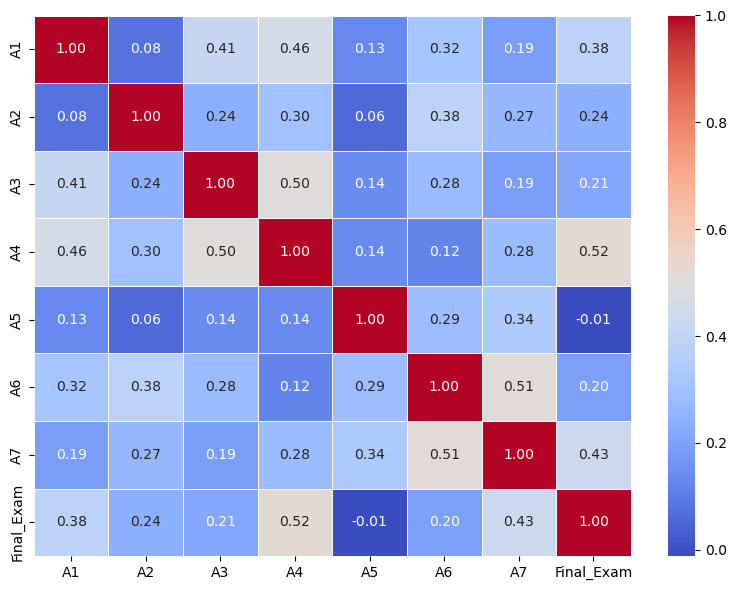

In [188]:
plot_heatmatrix (corr_matrix)

## Fill with median

In [189]:
def fill_median(df, column):
    df[column] = df[column].fillna(df[column].median())
    return df

df_fill_median = df.copy()

for assignment in assignment_cols:
    df_fill_median = fill_median(df_fill_median, assignment)

In [190]:
df_fill_median

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,87.5,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.2,100.0,80.0,80.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,95.0,80.0,80.0,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,87.5,91.1,80.0,56.2,95.0,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,80.0,146.4,64.1,U083
83,79.2,91.1,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,87.5,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


In [191]:
corr_matrix= correlation_check(df_fill_median)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.11  0.26  0.27  0.15  0.15 -0.02        0.18
A2         -0.11  1.00  0.16 -0.01 -0.00  0.24  0.03        0.22
A3          0.26  0.16  1.00  0.15  0.14  0.01  0.13        0.26
A4          0.27 -0.01  0.15  1.00  0.02  0.13  0.20        0.39
A5          0.15 -0.00  0.14  0.02  1.00  0.20  0.04        0.02
A6          0.15  0.24  0.01  0.13  0.20  1.00  0.14        0.21
A7         -0.02  0.03  0.13  0.20  0.04  0.14  1.00        0.35
Final_Exam  0.18  0.22  0.26  0.39  0.02  0.21  0.35        1.00


In [192]:
df_fill_median = remove_from_col(df_fill_median)

In [193]:
df_fill_median

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,87.5,91.1,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,91.1,80.0,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,80.0,86.2,100.0,80.0,80.0,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,91.1,0.0,0.0,95.0,80.0,80.0,0.0,U005
8,83.3,85.7,50.0,90.0,95.0,80.0,87.5,51.9,U009
10,75.0,75.0,90.0,96.2,100.0,80.0,80.0,55.6,U011
11,79.2,57.1,64.0,68.8,90.0,72.0,68.8,28.4,U012
13,87.5,91.1,35.0,87.5,40.0,60.0,55.0,61.3,U014
17,87.5,91.1,80.0,101.2,98.0,100.0,85.6,68.8,U018


In [194]:
corr_matrix= correlation_check(df_fill_median)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.08  0.38  0.46  0.12  0.30  0.16        0.38
A2          0.08  1.00  0.22  0.28  0.06  0.40  0.27        0.23
A3          0.38  0.22  1.00  0.50  0.16  0.32  0.21        0.28
A4          0.46  0.28  0.50  1.00  0.09  0.12  0.29        0.53
A5          0.12  0.06  0.16  0.09  1.00  0.28  0.34       -0.02
A6          0.30  0.40  0.32  0.12  0.28  1.00  0.51        0.18
A7          0.16  0.27  0.21  0.29  0.34  0.51  1.00        0.42
Final_Exam  0.38  0.23  0.28  0.53 -0.02  0.18  0.42        1.00


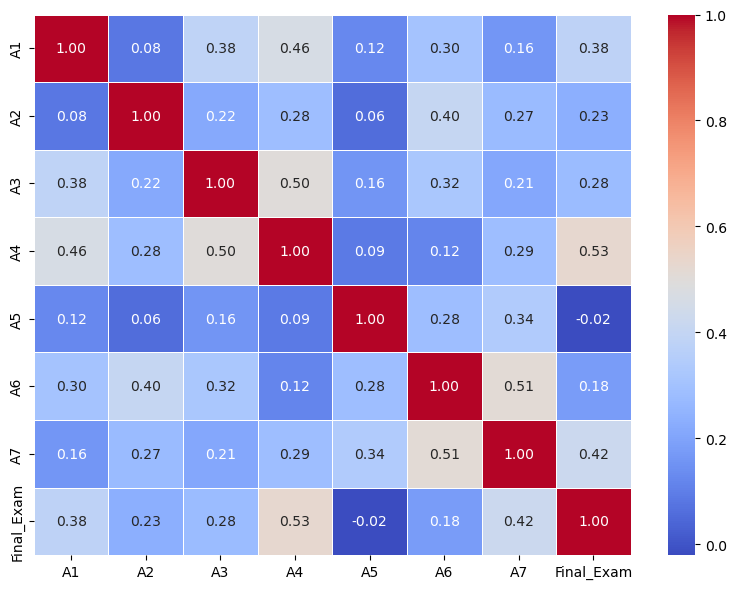

In [195]:
plot_heatmatrix (corr_matrix)

## Fill with interpolation

In [196]:
df_fill_inter = df.copy()
userid = df_fill_inter['user_id'].tolist() # create a list of user ids to add later after interpolation

df_fill_inter= df_fill_inter.drop(columns=['user_id']) # drop user id to be able to interpolate 

In [197]:
df_fill_inter=df_fill_inter.interpolate(method ='linear', limit_direction ='forward')

In [198]:
df_fill_inter['user_id'] =userid #add userid again after interpolation
df_fill_inter = df_fill_inter.dropna() # get rid of the two records at the start they remained nan as it is a forward interpolation 
df_fill_inter

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
2,75.00,69.60,36.666667,86.2,100.000000,65.35,42.20,67.8,U003
3,25.00,78.60,40.000000,0.0,50.000000,30.70,0.00,0.0,U004
4,0.00,85.75,0.000000,0.0,61.666667,55.35,55.25,0.0,U005
5,100.00,92.90,100.000000,96.2,73.333333,80.00,110.50,97.5,U006
6,95.80,64.30,63.000000,175.8,85.000000,76.00,83.80,64.4,U007
...,...,...,...,...,...,...,...,...,...
81,91.65,12.40,85.000000,56.2,90.500000,29.20,60.00,57.5,U082
82,87.50,-30.60,70.000000,174.8,91.000000,44.60,146.40,64.1,U083
83,79.20,-15.30,60.000000,27.5,50.000000,60.00,75.00,45.6,U084
84,83.35,0.00,85.000000,100.0,55.000000,0.00,0.00,30.6,U085


In [199]:
df_fill_inter = remove_from_col(df_fill_inter)

In [200]:
df_fill_inter

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
2,75.000000,69.600000,36.666667,86.2,100.000000,65.35,42.20,67.8,U003
3,25.000000,78.600000,40.000000,0.0,50.000000,30.70,0.00,0.0,U004
4,0.000000,85.750000,0.000000,0.0,61.666667,55.35,55.25,0.0,U005
8,83.300000,85.700000,50.000000,90.0,100.000000,80.00,87.50,51.9,U009
10,75.000000,75.000000,90.000000,96.2,100.000000,81.00,80.00,55.6,U011
11,79.200000,57.100000,64.000000,68.8,90.000000,72.00,68.80,28.4,U012
13,66.700000,96.450000,35.000000,83.7,40.000000,60.00,55.00,61.3,U014
18,83.300000,7.100000,84.600000,12.5,97.250000,100.00,72.50,54.7,U019
19,64.150000,100.000000,52.300000,88.8,96.500000,98.00,92.50,73.4,U020
20,45.000000,57.100000,20.000000,17.5,95.750000,96.00,78.80,57.5,U021


In [201]:
corr_matrix= correlation_check(df_fill_inter)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.02  0.40  0.45  0.15  0.45  0.21        0.37
A2          0.02  1.00  0.06  0.24  0.03  0.45  0.22        0.18
A3          0.40  0.06  1.00  0.42  0.06  0.20  0.23        0.23
A4          0.45  0.24  0.42  1.00  0.15  0.20  0.30        0.50
A5          0.15  0.03  0.06  0.15  1.00  0.25  0.29       -0.00
A6          0.45  0.45  0.20  0.20  0.25  1.00  0.55        0.31
A7          0.21  0.22  0.23  0.30  0.29  0.55  1.00        0.46
Final_Exam  0.37  0.18  0.23  0.50 -0.00  0.31  0.46        1.00


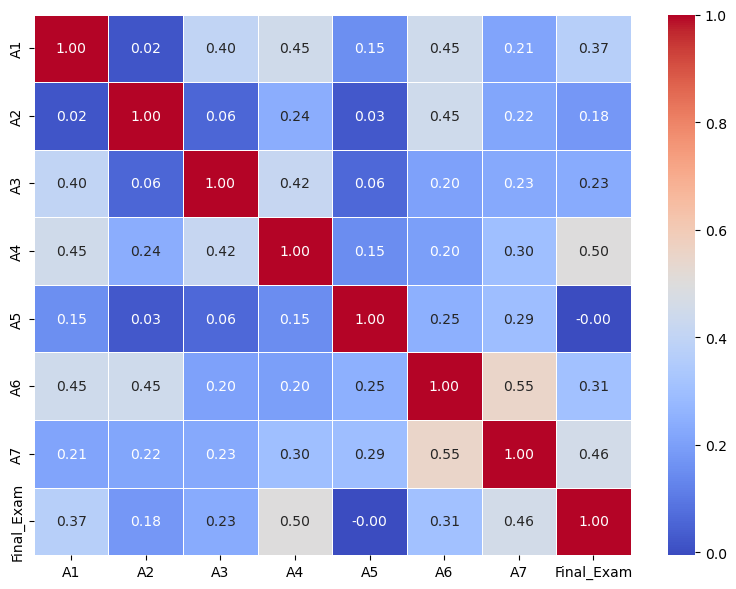

In [202]:
plot_heatmatrix (corr_matrix)

Removing all outliers is not ideal here 

in handling them I will consider all values in negative to be an artifact and that the absolute value is the true grade in the assignment 
all values that exceed 100 + bonus if applicable will be droped as I consider this an error that can't be retrived 

I considered replacing values that exceed 100 + bonus  but there was no way to understand where the error is like some could be considered an entry error 
where it was entered 187 instead of 87 or 18.7 but there is no way to tell or that it was 100 + bonus but bonus was not added correctly 

As for missing values removing them will limit the number of records we have while median and mean imputation did not change much in the correlation matrix 

interpolation is not a good idea here as there is more than one field missing per record this will lead to bad predictions as interpolation can fill the missing fields in with unusually high or low values creating outliers which will be adding to the problems here

I believe the best decision here is using the mean as it will be representing the mean performance of the class which won't bias our results 



## My decision is 

- absolute value of grades to get rid of negative values
- drop outliers over 100 + bonus
- use mean to replace missing values

In [209]:
final_df = df.copy()

### absolute value of grades to get rid of negative values

In [210]:
userid = final_df['user_id'].tolist() # create a list of user ids to add later after getting absolute values

final_df= final_df.drop(columns=['user_id']) # drop user id to be able to get absolute values

In [211]:
final_df = final_df.abs()

In [213]:
final_df['user_id'] =userid #adding ids back 

## drop outliers over 100 + bonus

In [214]:
final_df= remove_from_col(final_df)

In [215]:
final_df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,39.000000,41.000000,43.000000,53.000000,42.000000,48.000000,53.000000,60.000000
mean,77.479487,81.358537,67.390698,74.664151,83.307143,72.393750,74.505660,53.278333
std,26.146703,25.671453,30.393505,28.501546,22.627669,27.560799,19.517393,18.266094
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000,0.000000
25%,75.400000,69.600000,50.000000,61.300000,81.250000,60.000000,70.600000,42.100000
50%,83.300000,91.100000,80.000000,86.200000,91.000000,80.000000,78.800000,55.150000
75%,93.750000,96.400000,90.000000,95.000000,100.000000,95.000000,85.600000,66.825000
max,100.000000,114.300000,100.000000,102.500000,100.000000,110.000000,98.800000,90.000000


## use mean to replace missing values

In [216]:
for assignment in assignment_cols:
    final_df = fill_mean(final_df, assignment)
final_df

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,77.479487,81.358537,30.000000,75.000000,90.000000,65.00000,50.60000,68.8,U001
1,100.000000,81.358537,67.390698,92.500000,100.000000,100.00000,84.40000,50.3,U002
2,75.000000,69.600000,67.390698,86.200000,100.000000,72.39375,74.50566,67.8,U003
3,25.000000,78.600000,40.000000,0.000000,50.000000,30.70000,0.00000,0.0,U004
4,0.000000,81.358537,0.000000,0.000000,83.307143,72.39375,74.50566,0.0,U005
8,83.300000,85.700000,50.000000,90.000000,83.307143,80.00000,87.50000,51.9,U009
10,75.000000,75.000000,90.000000,96.200000,100.000000,72.39375,80.00000,55.6,U011
11,79.200000,57.100000,64.000000,68.800000,90.000000,72.00000,68.80000,28.4,U012
13,77.479487,81.358537,35.000000,74.664151,40.000000,60.00000,55.00000,61.3,U014
17,77.479487,91.100000,67.390698,101.200000,98.000000,100.00000,85.60000,68.8,U018


In [219]:
corr_matrix= correlation_check(final_df)

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00  0.11  0.39  0.38  0.14  0.29  0.22        0.40
A2          0.11  1.00  0.24  0.23  0.07  0.38  0.26        0.25
A3          0.39  0.24  1.00  0.41  0.21  0.36  0.18        0.24
A4          0.38  0.23  0.41  1.00  0.15  0.04  0.25        0.42
A5          0.14  0.07  0.21  0.15  1.00  0.30  0.32        0.05
A6          0.29  0.38  0.36  0.04  0.30  1.00  0.45        0.20
A7          0.22  0.26  0.18  0.25  0.32  0.45  1.00        0.43
Final_Exam  0.40  0.25  0.24  0.42  0.05  0.20  0.43        1.00


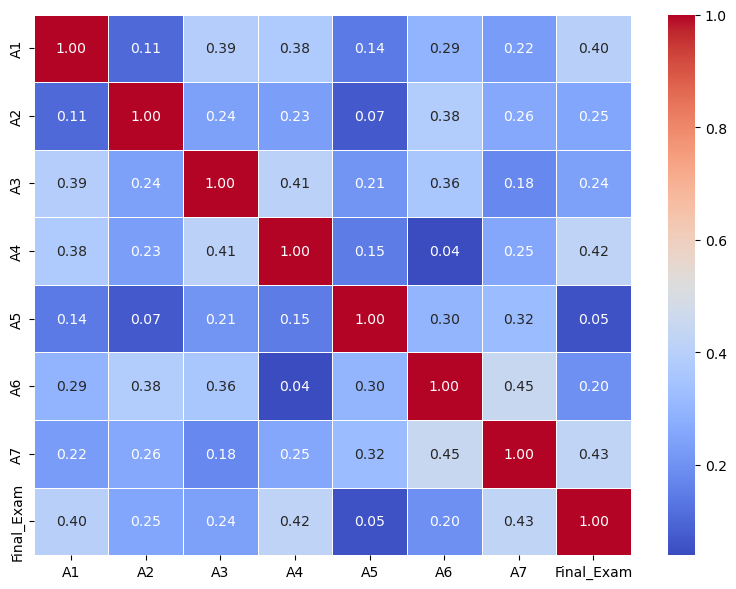

In [220]:
plot_heatmatrix (corr_matrix)

### we see now that the correlation coefficients changed after we handled missing values and outliers while there is now r > 0.5 meaning all relations
### are still weak we see that A1 (r= 0.40) can be used as a predictor with A4 (r = 0.42) and A7 (r=0.43) as they are the strongest relations we have.

### A2, A3, A5, and A6 all have correlation coefficients less than or equal to 0.25 which means there is no relation 